In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import pandas as pd
# from scipy.signal import find_peaks, savgol_filter, butter, freqz, filtfilt, medfilt
# from scipy.interpolate import PchipInterpolator, CubicSpline
# import re
from scipy.optimize import curve_fit

from functions import *

First linear fit (r^2 = 0.99957):
        d1 (nm) = 6565.9 +/- 26; m0_aprox = 27.784 +/- 0.082
Second linear fit (r^2 = 0.99939), with m0 fixed at 27.5:
        d2 (nm) = 6478.8 +/- 6.2
d2_std estimate (nm) = 25.8342667676232
mean(n2_std estimate) = 0.00650855281570445


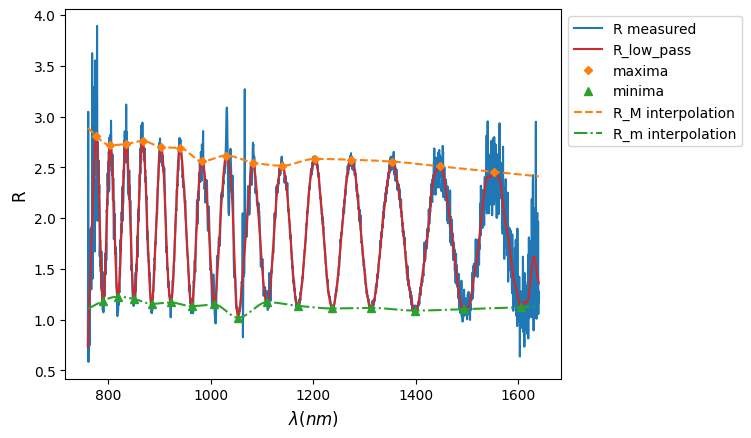

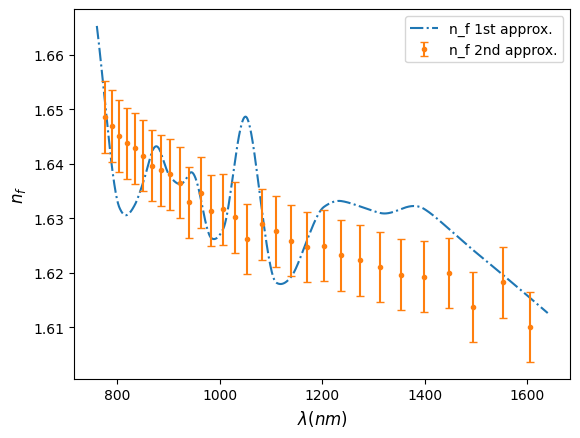

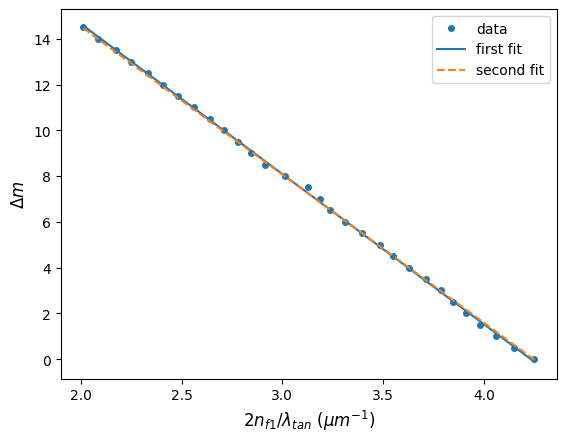

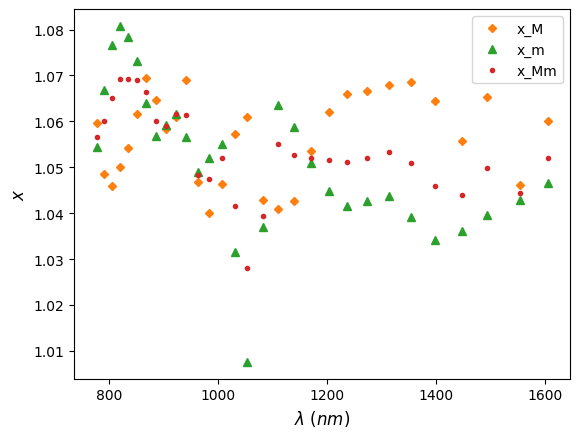

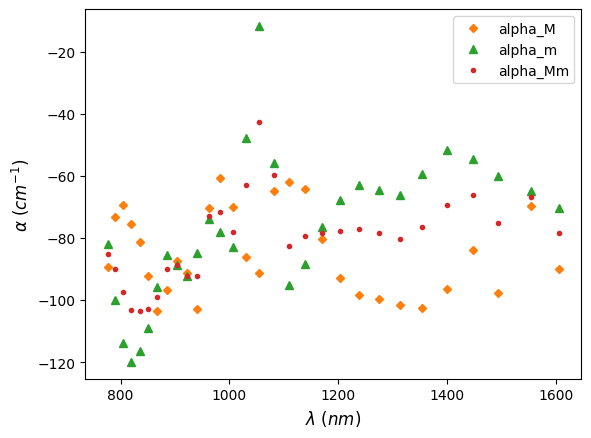

In [34]:
n_s_val = 1.4620 #substrate refractive index

diretorio = "Dados/OSA/2026-07-16"
meas_n = 10
sample_n = 2

start_wav, stop_wav = 760, 1640

#Initial reflection and transmission spectrum, without cavity.
df_r_i = trim_df(ler_OSA(f"{diretorio}/R{sample_n}/W0000.CSV"), start_wav, stop_wav)
df_t_i = trim_df(ler_OSA(f"{diretorio}/T{sample_n}/W0000.CSV"), start_wav, stop_wav)

# #Reflection and transmission spectrum, with cavity
df_r = trim_df(ler_OSA(f"{diretorio}/R{sample_n}/W{meas_n:04d}.CSV"), start_wav, stop_wav)
df_t = trim_df(ler_OSA(f"{diretorio}/T{sample_n}/W{meas_n:04d}.CSV"), start_wav, stop_wav)

# R_raw = df_r['Power lin']
R_raw = df_r["Power lin"]/df_r_i["Power lin"]*df_t_i["Power lin"]/df_t["Power lin"]
R = R_raw

wavs = df_r['Wavelength (nm)']

#Remove laser peak (if necessary)
laser_peak_start, laser_peak_stop = 1061, 1069
R_no_peak = remove_laser_peak(df_r["Wavelength (nm)"], R, laser_peak_start, laser_peak_stop)

fs = 1/(wavs[1]-wavs[0])
cutoff = 0.064
# for cutoff in np.arange(0.048, 0.08, 0.002):
R = R_no_peak
R_low_pass = butter_filter(R, cutoff, fs=fs)

R, R_label = R_low_pass, 'R_low_pass'

n_f_smaller = np.mean(R) < 1 #True if n_f < n_s
results = calc_values(R, wavs, n_s_val, n_f_smaller = n_f_smaller, peak_prominence = 0.4)
extr = np.sort(np.append(results['max_R'], results['min_R']))
m_spacing = np.arange(0, (len(extr))*0.5, 0.5)
x_axis = 2*results['n1'][extr]/wavs[extr]

# d2_std = results['d2_std']
d2_std = d2_std_estimate(results['d2_std'], results['m0_aprox_std'], x_axis) #results['m0_aprox_std'],np.abs(results['m0_exact']-results['m0_aprox'])
n2_std = n2_std_estimate(results['n2'], results['d2'], d2_std, wavs[extr], (wavs[1]-wavs[0])/2)

# print(f'cutoff = {cutoff}, d = {results["d2"]}, d2_std est = {d2_std}')

# use_n = results['n1'][extr]
use_n = results['n2']
x_M = calc_x_M(n_s_val, use_n, results['R_M_interp'](wavs[extr]), n_f_smaller)
x_m = calc_x_m(n_s_val, use_n, results['R_m_interp'](wavs[extr]), n_f_smaller)
x_Mm = calc_x_Mm(n_s_val, use_n, results['R_M_interp'](wavs[extr]), results['R_m_interp'](wavs[extr]))

alpha_M = -np.log(x_M)/(results['d2']*10**-7)
alpha_m = -np.log(x_m)/(results['d2']*10**-7)
alpha_Mm = -np.log(x_Mm)/(results['d2']*10**-7)

print(f'''First linear fit (r^2 = {results["r2_1"]:.5g}):
        d1 (nm) = {results["d1"]:.5g} +/- {results["d1_std"]:.2g}; m0_aprox = {results["m0_aprox"]:.5g} +/- {results["m0_aprox_std"]:.2g}''')

print(f'''Second linear fit (r^2 = {results["r2_2"]:.5g}), with m0 fixed at {results["m0_exact"]}:
        d2 (nm) = {results["d2"]:.5g} +/- {results["d2_std"]:.2g}''')
print(f'd2_std estimate (nm) = {d2_std}')
print(f'mean(n2_std estimate) = {np.mean(n2_std)}')


#------ Plots -------
font_size = 12

fig1 = plt.figure(1)
plt.plot(wavs, R_raw, label = 'R measured')
# plt.plot(df_r["Wavelength (nm)"], R_no_peak, label = 'R no peak')
plt.plot(wavs, R_low_pass, 'C3', label = R_label)
plt.plot(wavs[results['max_R']], R[results['max_R']], 'DC1', label = 'maxima', markersize = 4)
plt.plot(wavs[results['min_R']], R[results['min_R']], '^C2', label = 'minima')
plt.plot(wavs, results['R_M_interp'](wavs), '--C1', label = f'R_M interpolation')
plt.plot(wavs, results['R_m_interp'](wavs), '-.C2', label = f'R_m interpolation')
plt.legend(bbox_to_anchor=(1, 1),loc='upper left')
plt.xlabel(r'$\lambda (nm)$', fontsize = font_size)
plt.ylabel('R', fontsize = font_size)

fig2 = plt.figure(2)
plt.plot(wavs, results['n1'], '-.', label = f'n_f 1st approx.')
# plt.plot(wavs[extr], results['n2'], '.', label = f'n_f 2nd approx.')
plt.errorbar(wavs[extr], results['n2'], yerr = n2_std, fmt = '.', capsize = 3, label = f'n_f 2nd approx.')
plt.legend()
plt.xlabel(r'$\lambda (nm)$', fontsize = font_size)
plt.ylabel(r'$n_f$', fontsize = font_size)

factor, xlabel = 10**3, r'$2n_{f1}/\lambda_{tan}\ ({\mu m}^{-1})$'
fig3 = plt.figure(3)
plt.plot(x_axis*factor, m_spacing, 'o', label = f'data', markersize = 4)
plt.plot(x_axis*factor, -x_axis*results['d1']+results['m0_aprox'], '-C0', label = f'first fit') #f'first fit ({interpol}, {filter_name})'
plt.plot(x_axis*factor, -x_axis*results['d2']+results['m0_exact'], '--', label = f'second fit')
plt.ylabel(r'$\Delta m$', fontsize = font_size)
plt.xlabel(xlabel, fontsize = font_size)
plt.legend()

fig4 = plt.figure(4)
plt.plot(wavs[extr], x_M, 'DC1', label = 'x_M', markersize = 4)
plt.plot(wavs[extr], x_m, '^C2', label = 'x_m')
plt.plot(wavs[extr], x_Mm, '.C3', label = 'x_Mm')
plt.ylabel(r'$x$', fontsize = font_size)
plt.xlabel(r'$\lambda\ (nm)$', fontsize = font_size)
plt.legend()

fig5 = plt.figure(5)
plt.plot(wavs[extr], alpha_M, 'DC1', label = 'alpha_M', markersize = 4)
plt.plot(wavs[extr], alpha_m, '^C2', label = 'alpha_m')
plt.plot(wavs[extr], alpha_Mm, '.C3', label = 'alpha_Mm')
plt.ylabel(r'$\alpha\ (cm^{-1})$', fontsize = font_size)
plt.xlabel(r'$\lambda\ (nm)$', fontsize = font_size)
plt.legend()

plt.show()

# #--Save figure--
# direc = "Figuras/"
# fmt = 'pdf'
# dic = {'R_exp': fig1, 'n_exp': fig2, 'delta_m_vs_2nf1_lambda': fig3, 'x_exp': fig4, 'alpha_exp': fig5}
# save = ['R_exp', 'delta_m_vs_2nf1_lambda']
# for name in save:
#     dic[name].savefig(f'{direc}{name}.{fmt}', format=fmt, bbox_inches='tight')

Wemple-DiDomenico fit (r^2 = 0.98506):
        E0 = 5.6976 +/- 0.064; Ed = 9.0188 +/- 0.11


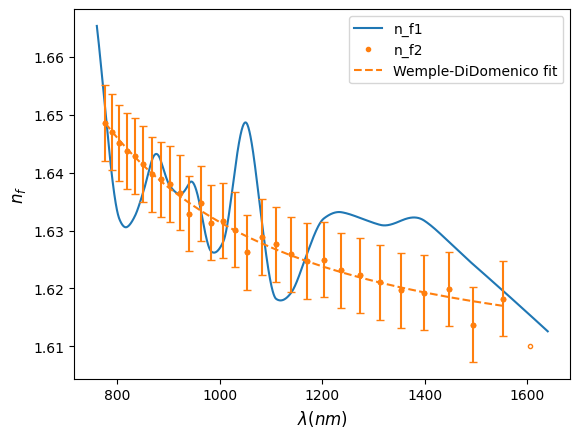

In [36]:
#Fit n2 to Wemple-DiDomenico equation
fit_start, fit_stop = 0, len(extr)-1
pa_n2, co_n2 = curve_fit(n_Wemple_DiDomenico, wavs[extr][fit_start:fit_stop], results["n2"][fit_start:fit_stop], p0=(5.55, 8.90))
fit_n2 = n_Wemple_DiDomenico(wavs[extr][fit_start:fit_stop], *pa_n2)
std_n2, r2_n2 = np.sqrt(np.diag(co_n2)), r_squared(results["n2"][fit_start:fit_stop], fit_n2)

print(f'''Wemple-DiDomenico fit (r^2 = {r2_n2:.5g}):
        E0 = {pa_n2[0]:.5g} +/- {std_n2[0]:.2g}; Ed = {pa_n2[1]:.5g} +/- {std_n2[1]:.2g}''')


fig = plt.figure()
plt.plot(df_r["Wavelength (nm)"], results['n1'], '-', label = 'n_f1')
plt.plot(wavs[extr], results["n2"], '.C1', markerfacecolor = 'none')
plt.plot(wavs[extr][fit_start:fit_stop], results['n2'][fit_start:fit_stop], '.C1', label = 'n_f2')
plt.errorbar(wavs[extr][fit_start:fit_stop], results["n2"][fit_start:fit_stop], yerr = n2_std[fit_start:fit_stop], fmt = '.C1', capsize = 3)
plt.plot(wavs[extr][fit_start:fit_stop], fit_n2, '--', color = 'C1', label = 'Wemple-DiDomenico fit')
plt.xlabel(r'$\lambda (nm)$', fontsize = font_size)
plt.ylabel(r'$n_f$', fontsize = font_size)
plt.legend()
plt.show()

# # #--Save figure--
# dir = "Figuras/"
# fmt = 'pdf'
# fig.savefig(f'{dir}n2_fit.{fmt}', format=fmt, bbox_inches='tight')